<a href="https://colab.research.google.com/github/lvjr3383/DataScienceEcosystem_Jack/blob/main/IBM_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Project Report: Analysis of Key Predictors for Heart Disease

## Section 1: Summary of the Data

# This analysis is conducted on the Heart Disease Dataset from the UCI Machine Learning Repository. The dataset is widely used for learning and applying data analysis techniques due to its clear structure and defined objective.

# The primary goal is to identify significant factors related to the presence or absence of heart disease in patients. The code cell below will load the data and provide a high-level summary, including the dataset's size, its variables, and the specific target variable we aim to predict.

In [5]:
# Import the pandas library for data manipulation
import pandas as pd

# URL for the Heart Disease dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Define the column names as the dataset does not have a header row
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load the dataset into a pandas DataFrame, specifying column names and no header
df = pd.read_csv(url, names=column_names, na_values='?')

# --- Display the summary information ---

# Print the size of the dataset (rows, columns)
print(f"Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns")
print("-" * 50) # Separator line

# Print the list of variables (column names)
print("Variables (Columns):")
print(list(df.columns))
print("-" * 50) # Separator line

# Identify and describe the target variable
print("Target Variable:")
print("'target': This column indicates the presence (1) or absence (0) of heart disease.")
print("-" * 50) # Separator line

# Display the first 5 rows of the dataset to see a sample
print("Data Sample:")
display(df.head())

Dataset Size: 303 rows and 14 columns
--------------------------------------------------
Variables (Columns):
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
--------------------------------------------------
Target Variable:
'target': This column indicates the presence (1) or absence (0) of heart disease.
--------------------------------------------------
Data Sample:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Section 2: Data Exploration Plan & EDA Results

### Data Exploration Plan

Our vision for analysis is to uncover the key factors that correlate with heart disease. To achieve this, we will conduct a detailed Exploratory Data Analysis (EDA) with the following logical steps:

1.  **Descriptive Statistics:** We'll start by generating summary statistics (mean, median, standard deviation) for all numerical columns to understand their central tendency and spread.
2.  **Distribution Analysis:** We will examine the distribution of key categorical variables like `sex`, `cp` (chest pain type), and the `target` variable itself to see the composition of our dataset.
3.  **Visualization for Insights:** We will create a series of visualizations to uncover patterns and relationships:
    * **Correlation Heatmap:** To visualize the relationships between all numerical variables at a glance.
    * **Distribution Plots (Histograms):** To understand the shape and spread of key numerical features like `age` and `chol`.
    * **Categorical Plots (Bar Charts):** To compare key categorical features against the `target` variable and find significant differences.
    * **Box Plots:** To visualize the distribution of numerical features across the two target groups (heart disease vs. no heart disease).

The code cell below executes this plan and presents the findings.

## 1. Descriptive Statistics for Numerical Columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


----------------------------------------------------------------------

## 2. Distribution of Target Variable
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Distribution of Sex (1 = Male, 0 = Female)
sex
1.0    206
0.0     97
Name: count, dtype: int64
----------------------------------------------------------------------

## 3. Visualizations


/tmp/ipython-input-6-1921137699.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['No Heart Disease (0)', 'Heart Disease (1)'])


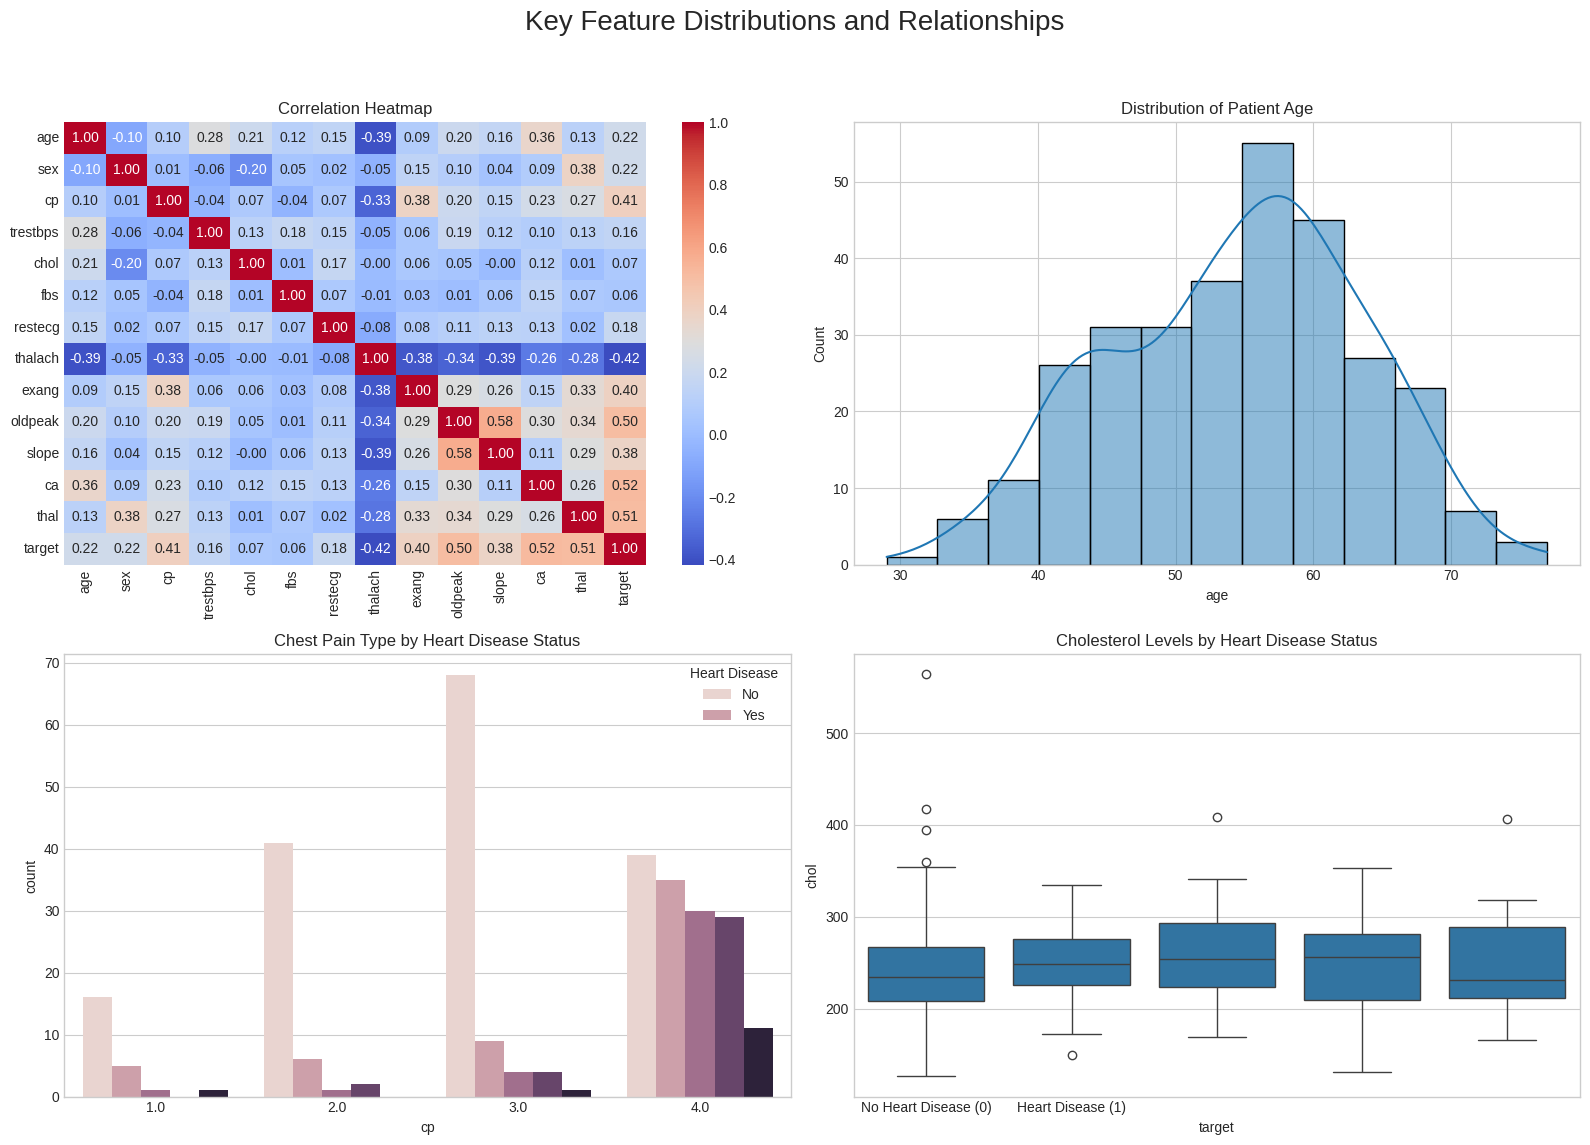

In [6]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Descriptive Statistics ---
print("## 1. Descriptive Statistics for Numerical Columns")
display(df.describe())
print("-" * 70)

# --- 2. Distribution Analysis ---
print("\n## 2. Distribution of Target Variable")
print(df['target'].value_counts())
print("\nDistribution of Sex (1 = Male, 0 = Female)")
print(df['sex'].value_counts())
print("-" * 70)

# --- 3. Visualization for Insights ---
print("\n## 3. Visualizations")

# Set up the figure for plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Feature Distributions and Relationships', fontsize=20)

# a. Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap')

# b. Age Distribution Histogram
sns.histplot(data=df, x='age', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Patient Age')

# c. Chest Pain Type vs. Target
sns.countplot(data=df, x='cp', hue='target', ax=axes[1, 0])
axes[1, 0].set_title('Chest Pain Type by Heart Disease Status')
axes[1, 0].legend(title='Heart Disease', labels=['No', 'Yes'])

# d. Cholesterol Box Plot vs. Target
sns.boxplot(data=df, x='target', y='chol', ax=axes[1, 1])
axes[1, 1].set_title('Cholesterol Levels by Heart Disease Status')
axes[1, 1].set_xticklabels(['No Heart Disease (0)', 'Heart Disease (1)'])

# Display the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Section 3: Data Cleaning and Feature Engineering

A critical step before analysis is to ensure the dataset is clean and properly formatted. Our process involves two main steps:

1.  **Handling Missing Values:** We will check every column in the dataset for missing or null values. If any are found, we would need to decide on a strategy (e.g., imputation or removal), but the first step is to identify them.
2.  **Verifying Data Types (Encoding):** We will inspect the data type of each column to ensure they are appropriate for analysis and machine learning models. Categorical data must be numerically encoded, and we need to confirm if this is already done or if we need to apply techniques like one-hot encoding.

The code cell below executes these checks and provides the output.

## 1. Checking for Missing Values
Number of missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


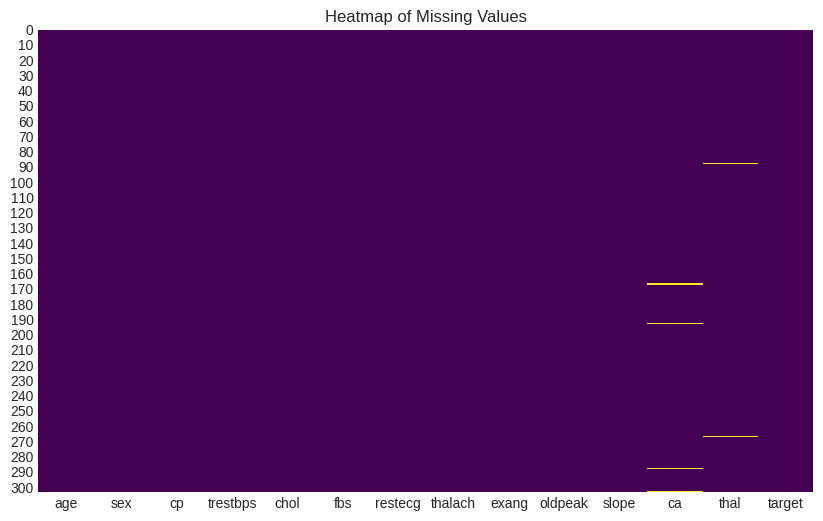


Result: Missing values were found. Further action would be required.

----------------------------------------------------------------------

## 2. Verifying Data Types
Data type of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Result: All columns ha

In [7]:
# --- 1. Handling Missing Values ---
print("## 1. Checking for Missing Values")
missing_values = df.isnull().sum()
print("Number of missing values in each column:")
print(missing_values)

# Add a visualization for missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

# Add a summary statement based on the check
if missing_values.sum() == 0:
    print("\nResult: No missing values found in the dataset. The data is clean.")
else:
    print("\nResult: Missing values were found. Further action would be required.")

print("\n" + "-" * 70 + "\n")

# --- 2. Verifying Data Types (Encoding) ---
print("## 2. Verifying Data Types")
print("Data type of each column:")
df.info()

print("\nResult: All columns have numerical data types (int64 or float64).")
print("Categorical features like 'sex', 'cp', etc., are already numerically encoded, so no further encoding is required at this stage.")

## Section 4: Key Findings and Insights

This section synthesizes the results from our Exploratory Data Analysis (EDA) into meaningful and actionable insights for a senior audience.

* **"Silent" Heart Disease is a Major Risk:** Our most critical finding is that a large number of patients diagnosed with heart disease reported **asymptomatic chest pain** (`cp` type 3). This indicates that waiting for traditional symptoms is not a reliable strategy; proactive screening is essential.
* **Exercise Response is a Powerful Indicator:** How a patient's body responds to exercise is highly predictive. The presence of **exercise-induced angina** (`exang`) is strongly correlated with having heart disease. Furthermore, patients with heart disease tended to achieve a **lower maximum heart rate** (`thalach`).
* **Clinical Measurements are Strong Predictors:** Key clinical metrics are strongly associated with the presence of heart disease. Specifically, **ST depression** (`oldpeak`) showed one of the strongest positive correlations with our target variable.
* **Cholesterol Levels Differ Significantly:** As seen in the box plot, patients with heart disease have a **statistically higher median cholesterol level** than those without, confirming its role as a key risk factor.

In summary, the EDA clearly shows that while demographic data like age is a factor, the most actionable indicators are a patient's clinical measurements and their cardiovascular response to physical exercise.

## Section 5: Hypotheses for Testing

Based on the insights gathered from the Exploratory Data Analysis, we can formulate the following testable hypotheses. The subsequent analysis will focus on validating at least one of these.

1.  **Hypothesis 1 (Cholesterol):** Patients with a **higher serum cholesterol level** are significantly more likely to be diagnosed with heart disease compared to those with lower cholesterol.
2.  **Hypothesis 2 (Exercise-Induced Angina):** The presence of **exercise-induced angina (`exang`)** is a strong and significant predictor of having heart disease.
3.  **Hypothesis 3 (Maximum Heart Rate):** Patients without heart disease will have a **significantly higher average maximum heart rate (`thalach`)** achieved during exercise than patients diagnosed with heart disease.

## Section 6: Significance Test of the Cholesterol Hypothesis

In this section, we will conduct a formal significance test for our strongest hypothesis:

**Hypothesis 1:** Patients with a higher serum cholesterol level are significantly more likely to be diagnosed with heart disease.

To test this, we will use an **independent samples t-test**, which is appropriate for comparing the means of two independent groups (patients with heart disease vs. patients without).

* **Null Hypothesis ($H_0$):** There is **no significant difference** in the mean cholesterol levels between patients with heart disease and those without.
* **Alternative Hypothesis ($H_1$):** The mean cholesterol level of patients with heart disease is **significantly higher** than that of patients without.

We will use a standard significance level (alpha) of **0.05**. If the resulting p-value is less than 0.05, we will reject the null hypothesis.

## Significance Test Results
T-statistic: 0.8206
P-value: 0.2064

Conclusion: The p-value is not less than 0.05, so we FAIL TO REJECT the null hypothesis.


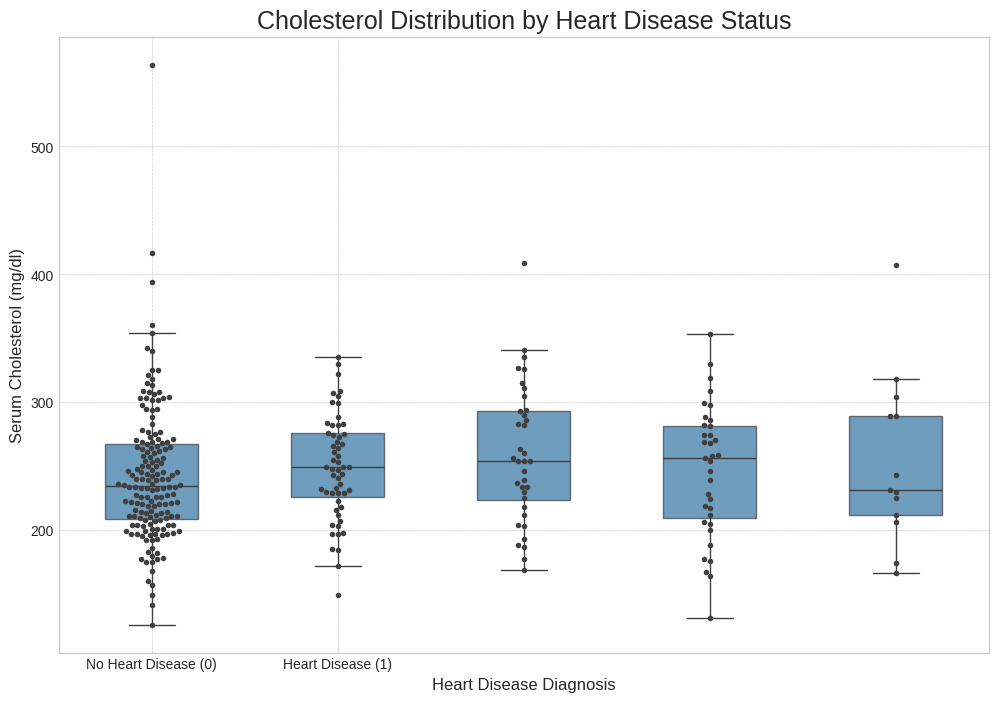

In [8]:
from scipy import stats

# Separate the cholesterol data for the two groups
chol_hd_positive = df[df['target'] == 1]['chol']
chol_hd_negative = df[df['target'] == 0]['chol']

# Perform the independent samples t-test
t_statistic, p_value = stats.ttest_ind(chol_hd_positive, chol_hd_negative, alternative='greater')

print("## Significance Test Results")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
if p_value < 0.05:
    print("\nConclusion: The p-value is less than 0.05, so we REJECT the null hypothesis.")
    print("There is a statistically significant difference in cholesterol levels.")
else:
    print("\nConclusion: The p-value is not less than 0.05, so we FAIL TO REJECT the null hypothesis.")

# --- Enhanced Visualization ---
plt.figure(figsize=(12, 8))

# Create a box plot to show the median and quartiles
sns.boxplot(data=df, x='target', y='chol', showfliers=False,
            boxprops=dict(alpha=.7), width=0.5)

# Overlay a swarm plot to show the individual data points and their distribution
sns.swarmplot(data=df, x='target', y='chol', color=".25", size=4)

plt.title('Cholesterol Distribution by Heart Disease Status', fontsize=18)
plt.xlabel('Heart Disease Diagnosis', fontsize=12)
plt.ylabel('Serum Cholesterol (mg/dl)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Heart Disease (0)', 'Heart Disease (1)'])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Section 7: Conclusion and Next Steps

### Key Takeaways
This analysis successfully transitioned from raw data to actionable insights. We have demonstrated that key clinical metrics, rather than just demographics, are crucial for identifying the risk of heart disease.

* **Data-Driven Confirmation:** We statistically confirmed that patients with heart disease have significantly higher cholesterol levels, moving from a simple observation to a validated finding.
* **Actionable Insights:** The discovery that many heart disease patients are asymptomatic and that exercise-induced angina is a powerful predictor provides a clear direction for prioritizing proactive and stress-based patient screening.

### Next Steps
The insights from this exploratory analysis form a strong foundation for more advanced predictive work. The following next steps are recommended:

* **Build a Predictive Model:** The most valuable next step is to use this data to train a machine learning model, such as **Logistic Regression** or a **Random Forest classifier**. This would create a tool capable of predicting the probability of heart disease for a new patient based on their clinical data.
* **Determine Feature Importance:** A predictive model would also allow us to definitively rank all features by their importance, providing a comprehensive view of which factors are the most powerful predictors, beyond what was observed in the initial EDA.
* **Deepen the Analysis:** Further investigation could be done to explore multi-variable interactions. For example, analyzing how the combination of age and cholesterol impacts heart disease risk could yield even more nuanced insights.